# C01 – Data Preparation & Leakage Control (M1) – Classification
**IT3051 Fundamentals of Data Mining – Mini Project 2026**
**Dataset:** DataCo Smart Supply Chain (Mendeley Data, DOI 10.17632/8gx2fvg2k6.1)
**Task:** Classification – predict **`Late_delivery_risk`** (1 = late, 0 = on time or early) **at the moment the order is placed**.
**Owner:** M1 (Lead / Data pipeline)

### What this notebook does
1. Loads the raw data correctly (Latin-1 encoding).
2. **Proves** with data which columns leak the answer, then removes them – including **Days for shipping (real)** and **Days for shipment (scheduled)**.
3. Removes cancelled / suspected-fraud orders (never shipped, so their label is meaningless).
4. Drops personal, empty, constant and duplicate columns – every drop is logged with a reason.
5. Creates **one shared train/test split, grouped by Order Id**, used by the whole team.
6. Sets two baselines that every later model must beat.

### Files it saves (all names contain `clf`, so they never overwrite the regression files)
| File | Used by |
|---|---|
| `data/processed/train_clf.csv`, `test_clf.csv` | C02 – C09 |
| `data/processed/split_meta_clf.json` | everyone, backend |
| `reports/drop_log_clf.csv` | report + viva |

**Run order:** `c01 → c02 → c03 → c04 → c05, c06, c07, c08 (any order) → c09`.
Put the raw file at `data/raw/DataCoSupplyChainDataset.csv` and run from the `notebooks/` folder.

## Step 0 – Setup
All paths and constants are defined once, so every run gives the same result (`SEED = 42`).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = ROOT / "data" / "raw" / "DataCoSupplyChainDataset.csv"
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Late_delivery_risk"                 # what we predict: 1 = late, 0 = on time / early
REAL = "Days for shipping (real)"             # NOT a feature: decides the answer
SCHED = "Days for shipment (scheduled)"       # NOT a feature: part of the answer's definition
GROUP = "Order Id"
SEED = 42
DATE_FMT = "%m/%d/%Y %H:%M"
print("Project root:", ROOT)

Project root: /Users/gayandesilva/Documents/Projects/dataco-late-delivery-predictor


## Step 1 – Load the raw data
### 1.1 Read the CSV
The file is **Latin-1 encoded, not UTF-8**. Reading it as UTF-8 fails or corrupts accented names (*Japón* → *JapÛn*).

In [2]:
raw = pd.read_csv(RAW_PATH, encoding="latin-1")
raw.columns = raw.columns.str.strip()
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}   Unique orders: {raw[GROUP].nunique():,}")

Rows: 180,519   Columns: 53   Unique orders: 65,752


### 1.2 Encoding check
Accented names should look normal (Japón, Seúl, ...).

In [3]:
accented = raw["Order Country"][raw["Order Country"].str.contains("[áéíóúñü]", regex=True, na=False)]
print(sorted(accented.unique())[:10])

['Afganistán', 'Arabia Saudí', 'Azerbaiyán', 'Bangladés', 'Baréin', 'Benín', 'Bután', 'Bélgica', 'Camerún', 'España']


## Step 2 – First look at the data
### 2.1 Overview of every column
Type, number of different values and % missing – the evidence for most data-quality issues.

In [4]:
overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "missing_%": (raw.isna().mean() * 100).round(2),
}).sort_values(["missing_%", "n_unique"], ascending=[False, True])
overview

,dtype,n_unique,missing_%
Product Description,float64,0,100.00
Order Zipcode,float64,609,86.24
Customer Email,object,1,0.00
Customer Password,object,1,0.00
Product Status,int64,1,0.00
Late_delivery_risk,int64,2,0.00
Customer Country,object,2,0.00
Customer Segment,object,3,0.00
Type,object,4,0.00
Days for shipment (scheduled),int64,4,0.00


### 2.2 The target: how many orders are late?
A yes/no target → **classification**. If the two classes are roughly balanced, no resampling is needed – but we still stratify the split
and judge models with more than accuracy.

Late_delivery_risk (% of rows):
 Late_delivery_risk
0    45.2
1    54.8
Name: proportion, dtype: float64


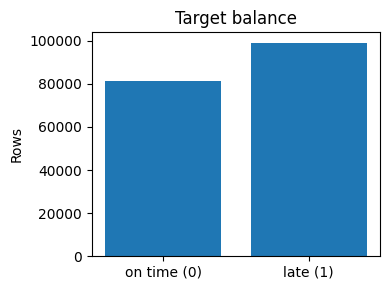

In [5]:
balance = raw[TARGET].value_counts(normalize=True).sort_index().mul(100).round(1)
print("Late_delivery_risk (% of rows):\n", balance)
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["on time (0)", "late (1)"], raw[TARGET].value_counts().sort_index().values)
ax.set_ylabel("Rows"); ax.set_title("Target balance")
plt.tight_layout(); plt.show()

## Step 3 – Prove the leakage
The model is used **when the order is placed**. Any column that defines the answer, or is only known after shipping, would let the
model cheat. Each cell below shows the evidence before the column is dropped.

### 3.1 `Days for shipping (real)` and `Days for shipment (scheduled)` define the label

In [6]:
rule = (raw[REAL] > raw[SCHED]).astype(int)
match_pct = (rule == raw[TARGET]).mean() * 100
print(f"{TARGET} == (real days > scheduled days) for {match_pct:.1f}% of rows")
print("\nRows breaking the rule, by Delivery Status:")
print(raw.loc[rule != raw[TARGET], "Delivery Status"].value_counts())

Late_delivery_risk == (real days > scheduled days) for 97.5% of rows

Rows breaking the rule, by Delivery Status:
Delivery Status
Shipping canceled    4423
Name: count, dtype: int64


→ The label is literally "real days > scheduled days". **Real days** are only known after shipping → leakage.
**Scheduled days** are part of the label's definition and are fixed by Shipping Mode (3.5) → not used either.
The few rows that break the rule are cancelled shipments (handled in Step 5).

### 3.2 `Delivery Status` is the label in words

In [7]:
pd.crosstab(raw["Delivery Status"], raw[TARGET])

Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,41592,0
Late delivery,0,98977
Shipping canceled,7754,0
Shipping on time,32196,0


→ "Late delivery" rows are all 1; the others are all 0 → leakage.

### 3.3 Shipping date = order date + real shipping days

In [8]:
order_dt = pd.to_datetime(raw["order date (DateOrders)"], format=DATE_FMT)
ship_dt = pd.to_datetime(raw["shipping date (DateOrders)"], format=DATE_FMT)
gap_days = (ship_dt - order_dt).dt.days
print(f"(shipping date - order date) in whole days == real shipping days for {(gap_days == raw[REAL]).mean() * 100:.1f}% of rows")

(shipping date - order date) in whole days == real shipping days for 97.4% of rows


→ The shipping date carries the real days, so it carries the answer → leakage.

### 3.4 `Order Status` is recorded after fulfilment

In [9]:
pd.crosstab(raw["Order Status"], raw[TARGET])

Late_delivery_risk,0,1
Order Status,,
CANCELED,3692,0
CLOSED,8507,11109
COMPLETE,25292,34199
ON_HOLD,4354,5450
PAYMENT_REVIEW,811,1082
PENDING,8515,11712
PENDING_PAYMENT,16910,22922
PROCESSING,9399,12503
SUSPECTED_FRAUD,4062,0


→ Used once to remove cancelled orders (Step 5), then dropped.

### 3.5 Scheduled days are fixed by Shipping Mode

In [10]:
pd.crosstab(raw["Shipping Mode"], raw[SCHED])

Days for shipment (scheduled),0,1,2,4
Shipping Mode,,,,
First Class,0,27814,0,0
Same Day,9737,0,0,0
Second Class,0,0,35216,0
Standard Class,0,0,0,107752


→ One scheduled value per mode, so Shipping Mode already carries this information. Scheduled days are dropped.

### 3.6 Do the profit columns depend on the label?
Big differences between late and on-time orders could mean profit was calculated after shipping (e.g. including delivery costs).

In [11]:
shipped = raw[~raw["Order Status"].isin(["CANCELED", "SUSPECTED_FRAUD"])]
shipped.groupby(TARGET)[["Benefit per order", "Order Item Profit Ratio"]].mean().round(3)

,Benefit per order,Order Item Profit Ratio
Late_delivery_risk,,
0,22.583,0.122
1,21.622,0.120


## Step 4 – Order-level structure (why the split must be grouped)
Each row is an **order item**. If all items of an order share the label, a random split would put "sibling" rows in train and test.

In [12]:
per_order = raw.groupby(GROUP).agg(items=(TARGET, "size"), n_label=(TARGET, "nunique"), n_mode=("Shipping Mode", "nunique"))
print("Items per order:\n", per_order["items"].describe().round(2), "\n")
print(f"Orders with more than one item: {(per_order['items'] > 1).mean() * 100:.1f}%")
print(f"Orders whose items have different labels:        {(per_order['n_label'] > 1).sum()}")
print(f"Orders whose items have different Shipping Mode: {(per_order['n_mode'] > 1).sum()}")

Items per order:
 count    65752.00
mean         2.75
std          1.48
min          1.00
25%          1.00
50%          3.00
75%          4.00
max          5.00
Name: items, dtype: float64 

Orders with more than one item: 69.8%
Orders whose items have different labels:        0
Orders whose items have different Shipping Mode: 0


## Step 5 – Remove cancelled and suspected-fraud orders
These orders were **never shipped**. They are labelled 0 ("not late") even when they took longer than scheduled – a misleading label.
They are removed **per order**.

In [13]:
EXCLUDE_STATUS = ["CANCELED", "SUSPECTED_FRAUD"]
bad_orders = raw.loc[raw["Order Status"].isin(EXCLUDE_STATUS), GROUP].unique()
excluded = raw[raw[GROUP].isin(bad_orders)]
late_but_zero = ((excluded[REAL] > excluded[SCHED]) & (excluded[TARGET] == 0)).sum()

print(f"Rows removed:   {len(excluded):,}")
print(f"Orders removed: {len(bad_orders):,}")
print(f"Removed rows that took longer than scheduled but are labelled 0: {late_but_zero:,}")

df = raw[~raw[GROUP].isin(bad_orders)].copy()
print(f"\nAfter filtering: {df.shape[0]:,} rows, {df[GROUP].nunique():,} orders, late {df[TARGET].mean() * 100:.1f}%")

Rows removed:   7,754
Orders removed: 2,855
Removed rows that took longer than scheduled but are labelled 0: 4,423

After filtering: 172,765 rows, 62,897 orders, late 57.3%


## Step 6 – Drop columns, each with a recorded reason
### 6.1 Find exactly duplicated columns

In [14]:
def same_values(a, b):
    if pd.api.types.is_numeric_dtype(a) and pd.api.types.is_numeric_dtype(b):
        return np.allclose(a.to_numpy(float), b.to_numpy(float), equal_nan=True)
    return a.astype(str).equals(b.astype(str))

n_unique = df.nunique(dropna=False)
cols = list(df.columns)
dup_pairs = [(c1, c2) for i, c1 in enumerate(cols) for c2 in cols[i + 1:]
             if n_unique[c1] == n_unique[c2] and same_values(df[c1], df[c2])]
for p in dup_pairs:
    print(" = ".join(p))

Benefit per order = Order Profit Per Order
Sales per customer = Order Item Total
Category Id = Product Category Id
Customer Email = Customer Password
Customer Id = Order Customer Id
Order Item Cardprod Id = Product Card Id
Order Item Product Price = Product Price


### 6.2 ID ↔ name pairs
A code column that matches a name one-to-one (Category Id ↔ Category Name) is the same feature twice – we keep the readable name.

In [15]:
def one_to_one(a, b):
    return df.groupby(a)[b].nunique().max() == 1 and df.groupby(b)[a].nunique().max() == 1

ID_NAME_PAIRS = [("Category Id", "Category Name"), ("Department Id", "Department Name"), ("Product Card Id", "Product Name")]
id_name_result = {f"{a} <-> {b}": one_to_one(a, b) for a, b in ID_NAME_PAIRS}
id_name_result

{'Category Id <-> Category Name': False,
 'Department Id <-> Department Name': True,
 'Product Card Id <-> Product Name': True}

### 6.3 Build the drop log
The target and Order Id are **protected** and never dropped.

In [16]:
drop_log = []
PROTECTED = {TARGET, GROUP}

def log_drop(columns, reason):
    for c in columns:
        if c in df.columns and c not in PROTECTED and c not in {d["column"] for d in drop_log}:
            drop_log.append({"column": c, "reason": reason})

# 1. Leakage / label definition
log_drop([REAL], "Leakage: real shipping days decide the label")
log_drop([SCHED], "Part of the label's definition (late = real > scheduled); fixed by Shipping Mode")
log_drop(["Delivery Status"], "Leakage: the label in words")
log_drop(["shipping date (DateOrders)"], "Leakage: order date + real shipping days")
log_drop(["Order Status"], "Leakage: recorded after fulfilment (used only to filter)")
# 2. Personal / masked data
log_drop(["Customer Email", "Customer Password"], "Masked (all 'XXXXXXXXX'), no information")
log_drop(["Customer Fname", "Customer Lname", "Customer Street", "Customer Zipcode"], "Personal data (PII)")
# 3. Empty, mostly missing or constant
for c in df.columns:
    miss = df[c].isna().mean() * 100
    if miss > 80:
        log_drop([c], f"{miss:.1f}% missing")
    elif df[c].nunique(dropna=True) <= 1:
        log_drop([c], "Constant: a single value in every row")
log_drop(["Product Image"], "Image URL: one per product, duplicates Product Name")
# 4. Exact duplicate columns
KEEP = {"Customer Id", "Product Card Id", "Category Id", "Benefit per order", "Sales per customer", "Product Price"}
for c1, c2 in dup_pairs:
    drop = c2 if c1 in KEEP or c2 not in KEEP else c1
    keep = c1 if drop == c2 else c2
    log_drop([drop], f"Exact duplicate of '{keep}'")
# 5. Code columns 1-to-1 with a readable name
for (a, b), ok in zip(ID_NAME_PAIRS, id_name_result.values()):
    if ok:
        log_drop([a], f"1-to-1 with '{b}' (same information as a code)")
# 6. Pure identifiers
log_drop(["Order Item Id"], "Row identifier")
log_drop(["Customer Id"], "Identifier: would let the model memorise customers")

drop_df = pd.DataFrame(drop_log)
drop_df

,column,reason
0,Days for shipping (real),Leakage: real shipping days decide the label
1,Days for shipment (scheduled),Part of the label's definition (late = real > ...
2,Delivery Status,Leakage: the label in words
3,shipping date (DateOrders),Leakage: order date + real shipping days
4,Order Status,Leakage: recorded after fulfilment (used only ...
5,Customer Email,"Masked (all 'XXXXXXXXX'), no information"
6,Customer Password,"Masked (all 'XXXXXXXXX'), no information"
7,Customer Fname,Personal data (PII)
8,Customer Lname,Personal data (PII)
9,Customer Street,Personal data (PII)


### 6.4 Apply the drops and save the log

In [17]:
df_clean = df.drop(columns=drop_df["column"]).reset_index(drop=True)
drop_df.to_csv(REPORTS_DIR / "drop_log_clf.csv", index=False)
assert REAL not in df_clean.columns and SCHED not in df_clean.columns
print(f"Dropped {len(drop_df)} columns -> {df_clean.shape[1]} remain")
print(df_clean.columns.tolist())

Dropped 25 columns -> 28 remain
['Type', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Region', 'Order State', 'Product Name', 'Product Price', 'Shipping Mode']


## Step 7 – Final quality checks

In [18]:
print("Exact duplicate rows:", df_clean.duplicated().sum())
remaining_missing = df_clean.isna().sum()
print("Columns with missing values:", remaining_missing[remaining_missing > 0].to_dict() or "none")
print(f"Clean shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns | late {df_clean[TARGET].mean() * 100:.1f}%")

Exact duplicate rows: 0
Columns with missing values: none
Clean shape: 172,765 rows x 28 columns | late 57.3%


## Step 8 – One shared train/test split, grouped by Order Id
`StratifiedGroupKFold` keeps every order in one set (**grouped**) and keeps the **same % of late orders** in both sets (**stratified**).
One of its 5 folds becomes the test set (≈20%). Nobody re-splits.

### 8.1 Create the split

In [19]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(sgkf.split(df_clean, df_clean[TARGET], groups=df_clean[GROUP]))
train = df_clean.iloc[train_idx].reset_index(drop=True)
test = df_clean.iloc[test_idx].reset_index(drop=True)

def summarise(name, d):
    return {"set": name, "rows": len(d), "orders": d[GROUP].nunique(),
            "share_of_rows_%": round(len(d) / len(df_clean) * 100, 1), "late_%": round(d[TARGET].mean() * 100, 2)}

split_summary = pd.DataFrame([summarise("full", df_clean), summarise("train", train), summarise("test", test)])
overlap = set(train[GROUP]) & set(test[GROUP])
print("Order Ids appearing in BOTH train and test:", len(overlap))
assert len(overlap) == 0
split_summary

Order Ids appearing in BOTH train and test: 0


,set,rows,orders,share_of_rows_%,late_%
0,full,172765,62897,100.0,57.29
1,train,138231,50318,80.0,57.18
2,test,34534,12579,20.0,57.73


### 8.2 Late rate in train vs test

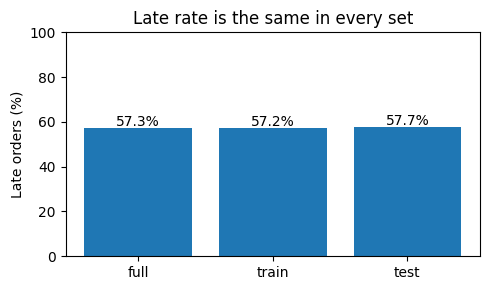

In [20]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(split_summary["set"], split_summary["late_%"])
for i, v in enumerate(split_summary["late_%"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
ax.set_ylabel("Late orders (%)"); ax.set_ylim(0, 100); ax.set_title("Late rate is the same in every set")
plt.tight_layout(); plt.show()

## Step 9 – Save the shared files

In [21]:
train.to_csv(PROCESSED_DIR / "train_clf.csv", index=False)
test.to_csv(PROCESSED_DIR / "test_clf.csv", index=False)
meta = {"task": "classification", "target": TARGET, "group": GROUP, "seed": SEED,
        "split": "StratifiedGroupKFold(n_splits=5) on the label, fold 0 = test",
        "excluded_order_status": EXCLUDE_STATUS, "dropped_columns": drop_df.to_dict(orient="records"),
        "remaining_columns": df_clean.columns.tolist(), "summary": split_summary.to_dict(orient="records")}
(PROCESSED_DIR / "split_meta_clf.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
print("Saved: train_clf.csv, test_clf.csv, split_meta_clf.json, reports/drop_log_clf.csv")

Saved: train_clf.csv, test_clf.csv, split_meta_clf.json, reports/drop_log_clf.csv


## Step 10 – Baselines every model must beat
Scored with grouped 5-fold cross-validation on the training set:
- **Always "late"** – the lazy guess. High recall, useless model; ROC-AUC = 0.5.
- **Shipping Mode only** – a logistic regression that only knows the shipping mode.

| Score | Simple meaning |
| --- | --- |
| Accuracy | % of orders guessed correctly |
| Precision | of orders called "late", % really late |
| Recall | of really-late orders, % caught (business priority) |
| F1 | balance of precision and recall |
| **ROC-AUC** | how well the model separates late from on-time (0.5 = random, 1 = perfect) – **main score** |

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

X_train, y_train, g_train = train.drop(columns=[TARGET]), train[TARGET], train[GROUP]
cv_splits = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X_train, y_train, g_train))
SCORING = {"accuracy": "accuracy", "precision": make_scorer(precision_score, zero_division=0),
           "recall": make_scorer(recall_score, zero_division=0), "f1": make_scorer(f1_score, zero_division=0),
           "roc_auc": "roc_auc"}
baselines = {
    "Always 'late'": DummyClassifier(strategy="constant", constant=1),
    "Shipping Mode only": Pipeline([("prep", ColumnTransformer([("mode", OneHotEncoder(handle_unknown="ignore"), ["Shipping Mode"])])),
                                    ("model", LogisticRegression(max_iter=1000))]),
}
rows = []
for name, model in baselines.items():
    s = cross_validate(model, X_train, y_train, cv=cv_splits, scoring=SCORING)
    rows.append({"baseline": name, **{m: s[f"test_{m}"].mean() for m in SCORING}})
baseline_table = pd.DataFrame(rows).set_index("baseline").round(4)
baseline_table

,accuracy,precision,recall,f1,roc_auc
baseline,,,,,
Always 'late',0.5718,0.5718,1.0000,0.7275,0.5000
Shipping Mode only,0.6968,0.8868,0.5385,0.6701,0.7414


## Step 11 – Viva summary

In [23]:
tr, te = split_summary.set_index("set").loc["train"], split_summary.set_index("set").loc["test"]
print(f'''
DATASET      DataCo Smart Supply Chain (Mendeley Data, DOI 10.17632/8gx2fvg2k6.1)
TASK         Classification - predict {TARGET} at order placement
RAW          {raw.shape[0]:,} rows x {raw.shape[1]} columns, {raw[GROUP].nunique():,} orders, late {raw[TARGET].mean() * 100:.1f}%
LABEL RULE   late == (real days > scheduled days) for {match_pct:.1f}% of rows
NOT FEATURES {REAL}, {SCHED}, Delivery Status, shipping date, Order Status
EXCLUDED     {len(excluded):,} rows / {len(bad_orders):,} orders (CANCELED, SUSPECTED_FRAUD)
DROPPED      {len(drop_df)} columns (reports/drop_log_clf.csv)
CLEAN        {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns
TRAIN / TEST {int(tr.rows):,} / {int(te.rows):,} rows, late {tr["late_%"]}% / {te["late_%"]}%, overlap {len(overlap)} orders
BASELINES    always late ROC-AUC {baseline_table.loc["Always 'late'", "roc_auc"]:.3f} | Shipping Mode ROC-AUC {baseline_table.loc["Shipping Mode only", "roc_auc"]:.3f}
''')


DATASET      DataCo Smart Supply Chain (Mendeley Data, DOI 10.17632/8gx2fvg2k6.1)
TASK         Classification - predict Late_delivery_risk at order placement
RAW          180,519 rows x 53 columns, 65,752 orders, late 54.8%
LABEL RULE   late == (real days > scheduled days) for 97.5% of rows
NOT FEATURES Days for shipping (real), Days for shipment (scheduled), Delivery Status, shipping date, Order Status
EXCLUDED     7,754 rows / 2,855 orders (CANCELED, SUSPECTED_FRAUD)
DROPPED      25 columns (reports/drop_log_clf.csv)
CLEAN        172,765 rows x 28 columns
TRAIN / TEST 138,231 / 34,534 rows, late 57.18% / 57.73%, overlap 0 orders
BASELINES    always late ROC-AUC 0.500 | Shipping Mode ROC-AUC 0.741



**My contribution in one sentence:** I loaded and cleaned the data, proved and removed the leakage columns (including real and
scheduled shipping days), built the shared train/test split grouped by Order Id, and set the baselines the whole team must beat.